# TP8 : Overfitting et validation

Importez les bibliothèques suivantes.

In [1]:
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt

Le TP précédent portait sur la régression linéaire. Le présent TP réutilisant la classe `MyRidgeRegression`, voici une cellule la définissant.

In [2]:
class MyRidgeRegression:
    def __init__(self):
        self.weights = None
        self.data = None
        self.output = None

    def fit(self, data, output, lambda_param):
        I = np.eye(data.shape[1])
        self.weights = np.linalg.inv(data.T @ data + lambda_param * I) @ data.T @ output
        self.data = data
        self.output = output

    def predict(self, data):
        return data @ self.weights

    def mse(self):
        predictions = self.predict(self.data)
        return np.mean((self.output - predictions)**2)

    def r2(self):
        predictions = self.predict(self.data)
        ss_res = np.sum((self.output - predictions)**2)
        ss_tot = np.sum((self.output - np.mean(self.output))**2)
        return 1 - (ss_res / ss_tot)

print("Classe MyRidgeRegression chargée.")

Classe MyRidgeRegression chargée.


Importez les jeux de données.

In [4]:
from google.colab import files
import io

data_to_load = files.upload()  # une fenêtre s'ouvrira pour choisir tes fichiers

df_pixels = pd.read_csv(io.BytesIO(data_to_load['pixels.csv']))
X = df_pixels.to_numpy(dtype="float32")
df_prices = pd.read_csv(io.BytesIO(data_to_load['prix.csv']))
y = df_prices.values

print(f"Forme de X : {X.shape}")
print(f"Nombre de prix : {len(y)}")

Saving prix.csv to prix.csv
Saving pixels.csv to pixels.csv
Forme de X : (2535, 784)
Nombre de prix : 2535


---

## Introduction : du jeu d'entraînement au jeu de test

Dans le TP précédent, nous avons entraîné et évalué nos modèles sur le même jeu de données. Cette approche pose un problème fondamental : un modèle peut très bien mémoriser les données d'entraînement (obtenir un faible MSE sur ces données) sans pour autant avoir appris à généraliser à de nouvelles données.

Ce phénomène s'appelle le surapprentissage (overfitting). Pour l'évaluer, il faut séparer nos données en un jeu d'entraînement (pour ajuster les poids du modèle) et un jeu de test (pour évaluer sa capacité de généralisation).

L'objectif de ce TP est de comprendre l'overfitting et d'apprendre à utiliser la validation croisée pour sélectionner les hyperparamètres de manière rigoureuse.

### Reproductibilité et graines aléatoires (seeds)

Le découpage train/test est aléatoire. Pour garantir la reproductibilité des résultats (obtenir les mêmes découpages à chaque exécution), on utilise une graine aléatoire (seed). La fonction `np.random.seed(valeur)` initialise le générateur de nombres aléatoires de NumPy avec une valeur fixe. Deux exécutions avec le même seed produiront exactement les mêmes nombres aléatoires, donc le même découpage.

Dans ce TP, nous explorerons également l'impact du choix du seed sur la stabilité des modèles. Un modèle robuste devrait donner des performances similaires quel que soit le découpage aléatoire des données.

## Exercice 1

1. Créez une fonction `train_test_split(data, labels, train_ratio=0.8, seed=42)` qui prend en entrée `data` et `labels`, mélange les indices avec `np.random.permutation` (**[documentation](https://numpy.org/doc/stable/reference/random/generated/numpy.random.permutation.html)**) après avoir fixé le seed avec `np.random.seed(seed)`, découpe selon `train_ratio`, et retourne `data_train`, `data_test`, `labels_train`, `labels_test`. Testez cette fonction en affichant les dimensions des ensembles retournés.

In [8]:
def train_test_split(data, labels, train_ratio=0.8, seed=42):
    np.random.seed(seed)
    indices = np.random.permutation(len(data))
    train = int(len(data) * train_ratio)
    index_train = indices[:train]
    index_test = indices[train:]
    return data[index_train], data[index_test], labels[index_train], labels[index_test]

data_train, data_test, labels_train, labels_test = train_test_split(X, y)

print(f"data_train : {data_train.shape}")
print(f"data_test : {data_test.shape}")
print(f"labels_train : {labels_train.shape}")
print(f"labels_test : {labels_test.shape}")

data_train : (2028, 784)
data_test : (507, 784)
labels_train : (2028, 1)
labels_test : (507, 1)


2. Pour étudier la stabilité du modèle, testez plusieurs découpages différents en variant le seed. Pour chacun des seeds suivants : `42`, `123`, `456`, `789`, `101`, `202`, `303`, `404`, `505`, `606`, créez un découpage train/test, entraînez un modèle Ridge avec `lambda = 1.0`, et stockez le MSE test. Affichez ensuite la moyenne et l'écart-type des MSE test obtenus. Refaites la même chose avec `lambda = 1000`. Affichez les résultats sous forme de tableau comparatif.

In [11]:
seeds = [42, 123, 456, 789, 101, 202, 303, 404, 505, 606]
res_l1 = []
res_l1000 = []

for s in seeds:
    X_train, X_test, y_train, y_test = train_test_split(X, y, seed=s)


    reg1 = MyRidgeRegression()
    reg1.fit(X_train, y_train, lambda_param=1.0)
    pred1 = reg1.predict(X_test)
    mse1 = np.mean((y_test - pred1)**2)
    res_l1.append(mse1)


    reg2 = MyRidgeRegression()
    reg2.fit(X_train, y_train, lambda_param=1000)
    pred2 = reg2.predict(X_test)
    mse2 = np.mean((y_test - pred2)**2)
    res_l1000.append(mse2)


df_comp = pd.DataFrame({
    "Seed": seeds,
    "MSE test avec λ=1": res_l1,
    "MSE test avec λ=1000": res_l1000
})

df_comp.loc[len(df_comp)] = ["Moyenne", np.mean(res_l1), np.mean(res_l1000)]
df_comp.loc[len(df_comp)] = ["Écart-type", np.std(res_l1), np.std(res_l1000)]

print(df_comp.to_string(index=False))

      Seed  MSE test avec λ=1  MSE test avec λ=1000
        42       54641.055511            643.959202
       123       36025.533347           1251.499003
       456       16410.087889            732.590130
       789       33846.591040           1011.729838
       101       13976.281030            682.776634
       202      137413.165922            690.706105
       303       27339.649722            892.962351
       404       60410.702349            876.664243
       505       18319.959524            752.032163
       606       56661.216397            813.547214
   Moyenne       45504.424273            834.846688
Écart-type       34659.167318            175.533785


3. Que constatez-vous sur la variabilité des résultats entre les deux valeurs de $\lambda$ ? Quel est le rôle de la régularisation par rapport à la stabilité du modèle ?

Avec lambda=1, les MSE test varient énormément d'un seed à l'autre (on a un écart-type très élevé. Le modèle est très instable,selon le découpage des données, on peut obtenir un MSE de 14 000 comme de 137 000. C'est un signe d'overfitting, le modèle colle trop aux données d'entraînement et généralise très mal.

Avec lambda=1000, les MSE test sont beaucoup plus stables (écart-type très faible). Les résultats sont proches quel que soit le seed, ce qui montre que le modèle généralise de façon cohérente.

La régularisation joue donc un rôle de stabilisation ,en pénalisant les poids trop grands, elle empêche le modèle de trop s'adapter au bruit présent dans le jeu d'entraînement. Un modèle régularisé est plus robuste face aux variations du découpage des données.

4. Les courbes d'apprentissage permettent de visualiser comment les performances évoluent en fonction de la taille du jeu d'entraînement. Pour différentes tailles de jeu d'entraînement (30%, 40%, 50%, 60%, 70%, 80%, 90%, 100% des données d'entraînement), entraînez un modèle Ridge avec `lambda = 1000` et calculez le MSE train et le MSE test. Tracez deux courbes sur le même graphique : MSE train en fonction de la taille et MSE test en fonction de la taille. Testez plusieurs seeds.

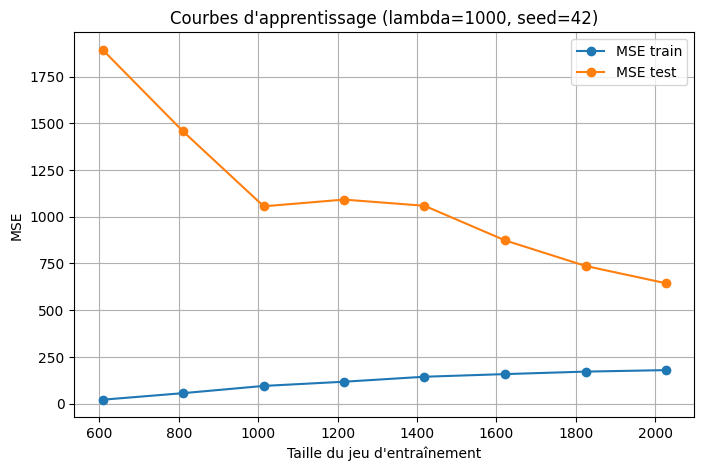

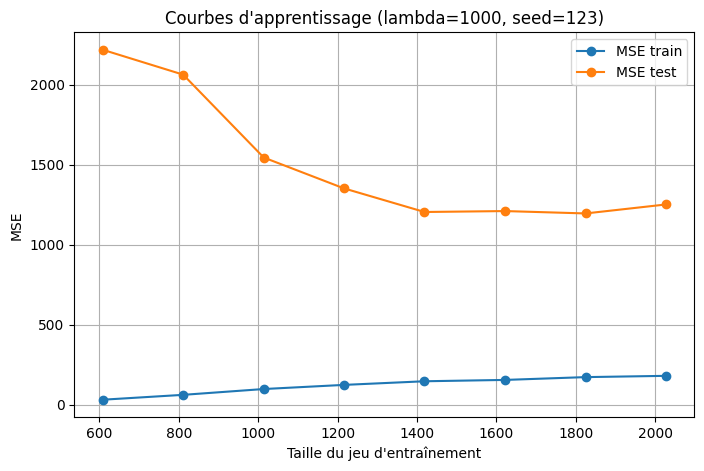

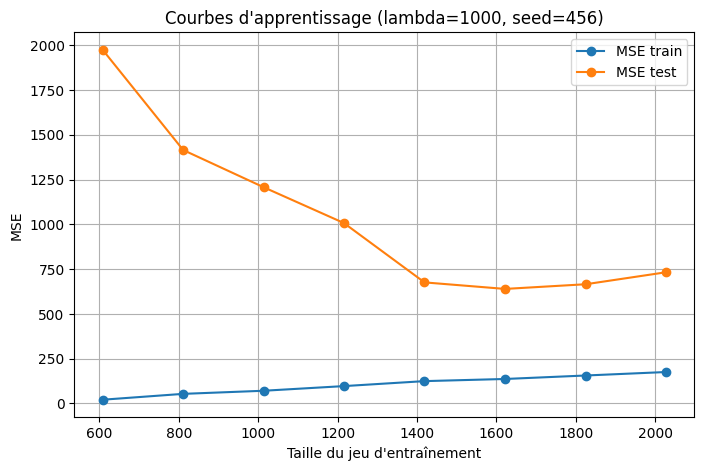

In [12]:
fractions = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

for seed in [42, 123, 456]:
    data_train, data_test, labels_train, labels_test = train_test_split(X, y, seed=seed)

    mse_trains = []
    mse_tests = []
    sizes = []

    for frac in fractions:
        n = int(len(data_train) * frac)
        X_sub = data_train[:n]
        y_sub = labels_train[:n]

        model = MyRidgeRegression()
        model.fit(X_sub, y_sub, lambda_param=1000)

        pred_train = model.predict(X_sub)
        pred_test = model.predict(data_test)

        mse_trains.append(np.mean((y_sub - pred_train)**2))
        mse_tests.append(np.mean((labels_test - pred_test)**2))
        sizes.append(n)

    plt.figure(figsize=(8, 5))
    plt.plot(sizes, mse_trains, 'o-', label='MSE train')
    plt.plot(sizes, mse_tests, 'o-', label='MSE test')
    plt.xlabel("Taille du jeu d'entraînement")
    plt.ylabel("MSE")
    plt.title(f"Courbes d'apprentissage (lambda=1000, seed={seed})")
    plt.legend()
    plt.grid(True)
    plt.show()

5. Que constatez-vous sur l'évolution du MSE train et du MSE test en fonction de la taille du jeu d'entraînement ? Comment l'écart entre les deux courbes évolue-t-il ?

Le MSE train augmente légèrement quand on ajoute des données, je pense que c'est normal parce qu'il est plus facile de bien coller à 600 exemples qu'à 2000. Le MSE test, lui, diminue quand on augmente la taille du jeu d'entraînement, car le modèle a plus d'information pour apprendre les vrais patterns.

L'écart entre les deux courbes se réduit au fur et à mesure qu'on ajoute des données. Avec peu de données, le modèle overfitte (MSE train bas, MSE test haut) mais avec plus de données les deux courbes convergent l'une vers l'autre. Cela montre qu'avoir plus de données aide à réduire l'overfitting.

## Exercice 2

Le paramètre de régularisation $\lambda$ contrôle la complexité du modèle. Un $\lambda$ trop petit peut conduire à l'overfitting (le modèle mémorise le bruit des données d'entraînement), tandis qu'un $\lambda$ trop grand peut conduire à l'underfitting (le modèle est trop simple pour capturer les patterns).

1. Pour différentes valeurs de `lambda` (`0.1`, `1`, `10`, `100`, `1000`, `10000`, `100000`, `1000000`, `10000000`, `100000000`, `1000000000`), entraînez un modèle Ridge sur le jeu d'entraînement complet et calculez le MSE train et le MSE test. Tracez les deux courbes sur le même graphique (échelle logarithmique pour les deux axes). Note : nous travaillons avec 784 paramètres, ce qui explique que les valeurs optimales de $\lambda$ sont très grandes.

lambda=1e-01 : MSE train=157.88, MSE test=444018.65
lambda=1e+00 : MSE train=161.10, MSE test=54641.06
lambda=1e+01 : MSE train=166.89, MSE test=3179.23
lambda=1e+02 : MSE train=172.33, MSE test=1260.78
lambda=1e+03 : MSE train=179.32, MSE test=643.96
lambda=1e+04 : MSE train=190.81, MSE test=542.39
lambda=1e+05 : MSE train=213.73, MSE test=458.96
lambda=1e+06 : MSE train=266.43, MSE test=398.31
lambda=1e+07 : MSE train=343.44, MSE test=410.75
lambda=1e+08 : MSE train=452.86, MSE test=496.80
lambda=1e+09 : MSE train=650.70, MSE test=656.67

Meilleur lambda (MSE test min) : 1e+06 avec MSE test = 398.31


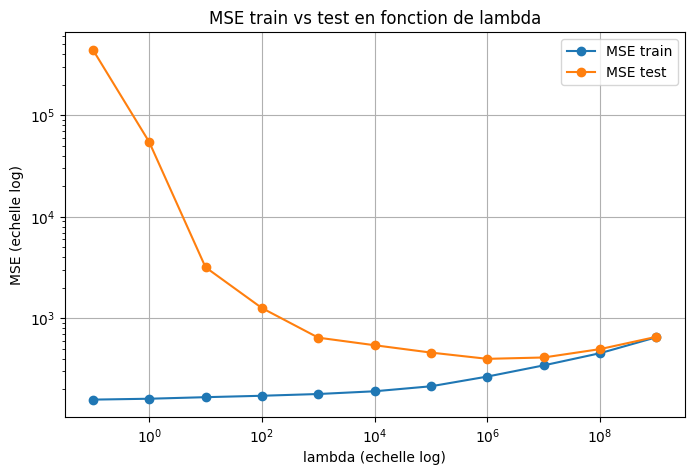

In [13]:
data_train, data_test, labels_train, labels_test = train_test_split(X, y, seed=42)

lambdas = [0.1, 1, 10, 100, 1000, 10000, 100000, 1000000, 10000000, 100000000, 1000000000]
mse_train_list = []
mse_test_list = []

for lam in lambdas:
    model = MyRidgeRegression()
    model.fit(data_train, labels_train, lambda_param=lam)

    prediction_train = model.predict(data_train)
    prediction_test = model.predict(data_test)

    mse_tr = np.mean((labels_train - prediction_train)**2)
    mse_te = np.mean((labels_test - prediction_test)**2)
    mse_train_list.append(mse_tr)
    mse_test_list.append(mse_te)
    print(f"lambda={lam:.0e} : MSE train={mse_tr:.2f}, MSE test={mse_te:.2f}")

best_idx = np.argmin(mse_test_list)
print(f"\nMeilleur lambda (MSE test min) : {lambdas[best_idx]:.0e} avec MSE test = {mse_test_list[best_idx]:.2f}")

plt.figure(figsize=(8, 5))
plt.loglog(lambdas, mse_train_list, 'o-', label='MSE train')
plt.loglog(lambdas, mse_test_list, 'o-', label='MSE test')
plt.xlabel("lambda (echelle log)")
plt.ylabel("MSE (echelle log)")
plt.title("MSE train vs test en fonction de lambda")
plt.legend()
plt.grid(True)
plt.show()

2. Identifiez la zone d'overfitting (petit $\lambda$) et la zone d'underfitting (grand $\lambda$). Quelle valeur de $\lambda$ minimise le MSE test ? Est-ce la même qui minimise le MSE train ?

La zone d'overfitting correspond aux petites valeurs de lambda (0.1 à 100 environ). Dans cette zone, le MSE train est très bas mais le MSE test explose, ce qui montre que le modèle mémorise les données sans généraliser.

La zone d'underfitting commence vers 10^8, les deux MSE augmentent car le modèle est trop contraint pour capturer quoi que ce soit.


Entre les deux, il y a une zone optimale autour de 10^5 à 10^7 où le MSE test est au plus bas. Le minimum est atteint à 10^6, mais les performances sont très proches pour 10^5 et 10^7. En effet,le lambda qui minimise le MSE test n'est pas celui qui minimise le MSE train, le MSE train est minimal pour les petits lambda, là où le modèle overfitte le plus.

## Exercice 3

L'exercice précédent pose un problème : nous avons utilisé le jeu de test pour choisir le meilleur $\lambda$. Or, le jeu de test doit rester "vierge" et ne servir qu'à l'évaluation finale du modèle. Si on l'utilise pour sélectionner les hyperparamètres, on risque de surajuster sur ce jeu de test.

La solution est la validation croisée (cross-validation). L'idée est de découper le jeu d'entraînement en k sous-ensembles (folds), d'entraîner k modèles (chacun sur k-1 folds et testé sur le fold restant), puis de moyenner les performances.

1. Construisez une fonction `cross_validate(data, labels, k_folds, lambda_param)` qui découpe `data` et `labels` en `k_folds` parties égales, entraîne `k` modèles Ridge avec le paramètre `lambda_param` donné, et retourne la moyenne des MSE obtenus sur chaque fold de validation. Utilisez cette fonction pour tester `k_folds = 5` avec `lambda_param = 10000`.

In [14]:
def cross_validate(data, labels, k_folds, lambda_param):
    n = len(data)
    fold_size = n // k_folds
    mse_list = []

    for i in range(k_folds):
        start = i * fold_size
        end = start + fold_size

        data_val = data[start:end]
        labels_val = labels[start:end]
        data_tr = np.concatenate([data[:start], data[end:]])
        labels_tr = np.concatenate([labels[:start], labels[end:]])

        model = MyRidgeRegression()
        model.fit(data_tr, labels_tr, lambda_param=lambda_param)
        pred = model.predict(data_val)
        mse = np.mean((labels_val - pred)**2)
        mse_list.append(mse)

    return np.mean(mse_list)

mse_cv = cross_validate(data_train, labels_train, k_folds=5, lambda_param=10000)
print(f"MSE cross-validation (k=5, lambda=10000) : {mse_cv:.2f}")

MSE cross-validation (k=5, lambda=10000) : 646.18


2. Utilisez la validation croisée pour sélectionner le meilleur $\lambda$ parmi les valeurs testées précédemment. Pour chaque valeur, calculez le MSE cross-validation. Affichez les résultats et identifiez le meilleur $\lambda$.

In [15]:
mse_cv_list = []

for lam in lambdas:
    mse_cv = cross_validate(data_train, labels_train, k_folds=5, lambda_param=lam)
    mse_cv_list.append(mse_cv)
    print(f"lambda={lam:.0e} : MSE CV = {mse_cv:.2f}")

best_cv_idx = np.argmin(mse_cv_list)
best_lambda_cv = lambdas[best_cv_idx]
print(f"\nMeilleur lambda par CV : {best_lambda_cv:.0e} avec MSE CV = {mse_cv_list[best_cv_idx]:.2f}")

lambda=1e-01 : MSE CV = 306029.36
lambda=1e+00 : MSE CV = 51468.45
lambda=1e+01 : MSE CV = 7848.10
lambda=1e+02 : MSE CV = 1911.44
lambda=1e+03 : MSE CV = 965.60
lambda=1e+04 : MSE CV = 646.18
lambda=1e+05 : MSE CV = 463.80
lambda=1e+06 : MSE CV = 379.98
lambda=1e+07 : MSE CV = 386.42
lambda=1e+08 : MSE CV = 474.58
lambda=1e+09 : MSE CV = 697.38

Meilleur lambda par CV : 1e+06 avec MSE CV = 379.98


3. Comparez le $\lambda$ sélectionné par validation croisée avec celui qui minimisait le MSE test dans l'exercice 2. Sont-ils identiques ? Même si les performances finales sont similaires, expliquez pourquoi la méthode par validation croisée est méthodologiquement supérieure.

Les deux méthodes donnent le même lambda optimal (10^6), ce qui est rassurant. Mais la méthode par validation croisée est bien meilleure sur le plan méthodologique.

Dans l'exercice 2, on a utilisé le jeu de test pour choisir lambda. Le problème c'est que le jeu de test est censé simuler des données jamais vues. Si on l'utilise pour régler nos hyperparamètres, on adapte le modèle à ces données, et le MSE test qu'on obtient à la fin n'est plus une estimation fiable de la vraie performance du modèle sur des données nouvelles.

La validation croisée résout ce problème, elle ne touche jamais au jeu de test. Elle utilise uniquement le jeu d'entraînement, qu'elle découpe en folds pour simuler un mini jeu de test interne. Le vrai jeu de test reste vierge et peut servir à la fin pour une vraie évaluation.

## Exercice 4 (Bonus)

1. Que se passe-t-il quand $\lambda$ devient très grand (tend vers l'infini) dans la formule Ridge : $\mathbf{w} = (\mathbf{X}^T \mathbf{X} + \lambda \mathbf{I})^{-1} \mathbf{X}^T \mathbf{y}$ ? Vers quelle valeur tendent les poids ?

Quand lambda tend vers l'infini,  dans w le terme lambda*I domine complètement X^T @ X dans la matrice à inverser. On obtient approximativement w = (lambda*I)^(-1) @ X^T @ y = (1/lambda) * X^T @ y. Comme 1/lambda tend vers 0, tous les poids tendent vers 0.

Concrètement le modèle ne fait plus rien, avec des poids nuls, les prédictions sont toutes proches de 0, quelle que soit l'entrée. Le modèle perd toute capacité à distinguer les exemples entre eux.

2. Entraînez deux modèles Ridge sur le jeu d'entraînement : un avec $\lambda = 1$ et un avec $\lambda = 10^{15}$ (régularisation extrême). Pour chaque modèle, calculez le MSE test, affichez les 10 premières prédictions avec les vraies valeurs correspondantes, ainsi que le minimum et le maximum des prédictions. Que constatez-vous sur le comportement des deux modèles ?

In [18]:
data_train, data_test, labels_train, labels_test = train_test_split(X, y, seed=42)


model_l1 = MyRidgeRegression()
model_l1.fit(data_train, labels_train, lambda_param=1.0)
pred_l1 = model_l1.predict(data_test)
mse_l1 = np.mean((labels_test - pred_l1)**2)

print("----- Lambda = 1 -----")
print(f"MSE test : {mse_l1:.2f}")
print("10 premieres predictions vs vraies valeurs :")
for i in range(10):
    print(f"  pred = {pred_l1[i][0]:.2f}, vrai = {labels_test[i][0]:.2f}")
print(f"Min prediction : {np.min(pred_l1):.2f}")
print(f"Max prediction : {np.max(pred_l1):.2f}")




model_big = MyRidgeRegression()
model_big.fit(data_train, labels_train, lambda_param=1e15)
pred_big = model_big.predict(data_test)
mse_big = np.mean((labels_test - pred_big)**2)

print("\n ----- Lambda = 1e15 -----")
print(f"MSE test : {mse_big:.2f}")
print("10 premieres predictions vs vraies valeurs :")
for i in range(10):
    print(f"  pred = {pred_big[i][0]:.2f}, vrai = {labels_test[i][0]:.2f}")
print(f"Min prediction : {np.min(pred_big):.2f}")
print(f"Max prediction : {np.max(pred_big):.2f}")

----- Lambda = 1 -----
MSE test : 54641.06
10 premieres predictions vs vraies valeurs :
  pred = 70.37, vrai = 76.49
  pred = 230.42, vrai = 143.81
  pred = 135.10, vrai = 91.99
  pred = 161.42, vrai = 160.26
  pred = 117.35, vrai = 131.40
  pred = 178.07, vrai = 139.56
  pred = 55.82, vrai = 50.00
  pred = 99.24, vrai = 66.93
  pred = 60.19, vrai = 60.45
  pred = 125.86, vrai = 110.32
Min prediction : -947.46
Max prediction : 5079.71

 ----- Lambda = 1e15 -----
MSE test : 8692.47
10 premieres predictions vs vraies valeurs :
  pred = 0.00, vrai = 76.49
  pred = 0.00, vrai = 143.81
  pred = 0.00, vrai = 91.99
  pred = 0.00, vrai = 160.26
  pred = 0.00, vrai = 131.40
  pred = 0.00, vrai = 139.56
  pred = 0.00, vrai = 50.00
  pred = 0.00, vrai = 66.93
  pred = 0.00, vrai = 60.45
  pred = 0.00, vrai = 110.32
Min prediction : 0.00
Max prediction : 0.00


3. D'après vos observations, le MSE seul est-il une métrique suffisante pour détecter ce type de problème ? Proposez une approche ou une métrique complémentaire qui permettrait d'identifier qu'un modèle ne fait rien d'utile. Implémentez cette métrique pour les deux modèles ($\lambda = 1$ et $\lambda = 10^{15}$) et comparez avec un modèle Ridge ayant un $\lambda$ optimal (celui trouvé dans l'exercice 3).

In [19]:
def r2_test(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2)
    return 1 - (ss_res / ss_tot)


model_opt = MyRidgeRegression()
model_opt.fit(data_train, labels_train, lambda_param=best_lambda_cv)
pred_opt = model_opt.predict(data_test)

print(f"R2 sur le test :")
print(f"  lambda = 1        : R2 = {r2_test(labels_test, pred_l1):.4f}")
print(f"  lambda = 1e15     : R2 = {r2_test(labels_test, pred_big):.4f}")
print(f"  lambda = {best_lambda_cv:.0e} (optimal) : R2 = {r2_test(labels_test, pred_opt):.4f}")

R2 sur le test :
  lambda = 1        : R2 = -45.1192
  lambda = 1e15     : R2 = -6.3368
  lambda = 1e+06 (optimal) : R2 = 0.6638


Le MSE seul ne suffit pas à détecter qu'un modèle ne fait rien d'utile. Par exemple, le modèle avec lambda=1e15 a un MSE de 8692, ce qui est bien plus bas que celui de lambda=1 (54641). On pourrait croire qu'il est meilleur. Mais en regardant les prédictions, il prédit 0.00 pour tout le monde,il n'a rien appris du tout.
Le R² résout ce problème. Il compare l'erreur du modèle à celle d'un modèle naïf qui prédirait toujours la moyenne. Un R² de 1 c'est modèle parfait, un R² de 0 c'est un modèle fait aussi bien que prédire la moyenne, un R² négatif le modèle fait pire que la moyenne.
Les résultats sont clairs , lambda=1 donne un R² de -45.12 (overfitting, prédictions qui vont de -947 à 5079), lambda=1e15 donne un R² de -6.34 (underfitting, tout à 0), et le lambda optimal (10^6) donne un R² de 0.66, ce qui montre que ce modèle capture vraiment la structure des données.